**We will implement various different Feature Engineering Stratergies and compare results**

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/animeguylrn/us-accidents-eda/US Accidents Model-Free Processed Data.parquet
/kaggle/input/notebooks/animeguylrn/us-accidents-eda/__results__.html
/kaggle/input/notebooks/animeguylrn/us-accidents-eda/__notebook__.ipynb
/kaggle/input/notebooks/animeguylrn/us-accidents-eda/__output__.json
/kaggle/input/notebooks/animeguylrn/us-accidents-eda/custom.css


In [2]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.4 MB/s eta 0:00:00a 0:00:01


In [4]:
from sklearn import set_config

set_config(transform_output="pandas")

In [5]:
lf = pl.scan_parquet('/kaggle/input/notebooks/animeguylrn/us-accidents-eda/US Accidents Model-Free Processed Data.parquet')

df = (
    lf
    .collect()
    .to_pandas(use_pyarrow_extension_array=False)
)

del lf

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 42 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Source                 uint8         
 1   Severity               uint8         
 2   Start_Time             datetime64[us]
 3   End_Time               datetime64[us]
 4   Start_Lat              float64       
 5   Start_Lng              float64       
 6   End_Lat                float64       
 7   End_Lng                float64       
 8   Distance(mi)           float64       
 9   Street                 object        
 10  City                   object        
 11  County                 object        
 12  State                  object        
 13  Timezone               object        
 14  Temperature(F)         float64       
 15  Wind_Chill(F)          float64       
 16  Humidity(%)            float64       
 17  Pressure(in)           float64       
 18  Visibility(mi)        

In [7]:
categorical_columns = ['Street','City','County','State','Timezone','Wind_Direction','Weather_Condition']

for col in categorical_columns:
    df[col] = df[col].astype('category')

datetime_columns = ['Start_Time','End_Time','Start_Date']
weather_columns = ['Temperature(F)','Wind_Chill(F)','Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)','Precipitation(in)'] # Numerical Only For Now
light_cols = ['Sunrise_Sunset','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 42 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Source                 uint8         
 1   Severity               uint8         
 2   Start_Time             datetime64[us]
 3   End_Time               datetime64[us]
 4   Start_Lat              float64       
 5   Start_Lng              float64       
 6   End_Lat                float64       
 7   End_Lng                float64       
 8   Distance(mi)           float64       
 9   Street                 category      
 10  City                   category      
 11  County                 category      
 12  State                  category      
 13  Timezone               category      
 14  Temperature(F)         float64       
 15  Wind_Chill(F)          float64       
 16  Humidity(%)            float64       
 17  Pressure(in)           float64       
 18  Visibility(mi)        

**Step 0 - Handeling Bad Data/Outliers**

Firstly, Lets see the weather data

In [12]:
df[weather_columns].describe()

,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
count,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06
mean,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00
std,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00
min,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00
50%,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00
75%,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01
max,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03


Notice We have absurd data at places, we will see what to do with them

Physical Limits imposed -
* Temperature $\in [-60,130]$ $^{o}$F
* Humidity $\in [1,100]$ %
* Pressure $\in [25,32.5]$ in
* Visibility $\in [0,20]$ mi
* Wind Speed $\in [0,150]$ mph

In [ ]:
invalid_weather = (
    (df["Temperature(F)"] < -60) |
    (df["Temperature(F)"] > 130) |

    (df["Humidity(%)"] < 1) |
    (df["Humidity(%)"] > 100) |

    (df["Pressure(in)"] < 25) |
    (df["Pressure(in)"] > 32.5) |

    (df["Visibility(mi)"] < 0) |
    (df["Visibility(mi)"] > 20) |

    (df["Wind_Speed(mph)"] < 0) |
    (df["Wind_Speed(mph)"] > 150)
)

bad_weather_rows = df[invalid_weather]

bad_weather_rows.shape

In [ ]:
df[
    [
        "Temperature(F)",
        "Humidity(%)",
        "Pressure(in)",
        "Visibility(mi)",
        "Wind_Speed(mph)"
    ]
].quantile(
    [0.001, 0.01, 0.99, 0.999]
)

Checking which feature contributes how much

In [ ]:
WEATHER_LIMITS = {
    "Temperature(F)": (-60, 130),
    "Humidity(%)": (1, 100),
    "Pressure(in)": (25, 32.5),
    "Visibility(mi)": (0, 20),
    "Wind_Speed(mph)": (0, 150)
}

for column, (lower, upper) in WEATHER_LIMITS.items():

    invalid_mask = (
    df[column].notna()
    &
    ~df[column].between(lower, upper)
    )

    count = invalid_mask.sum()

    percentage = invalid_mask.mean() * 100

    print(
        f"{column:<20} "
        f"Invalid: {count:>8,} "
        f"({percentage:.4f}%)"
    )

In [ ]:
pressure = df["Pressure(in)"]
pressure.describe(
    percentiles=[0.001, 0.01, 0.05, 0.95, 0.99, 0.999]
)

This suggests that the lower bound for pressure is too aggressive, we loose it a bit

In [ ]:
invalid_weather = (
    (df["Temperature(F)"] < -60) |
    (df["Temperature(F)"] > 130) |

    (df["Humidity(%)"] < 1) |
    (df["Humidity(%)"] > 100) |

    (df["Pressure(in)"] < 20) |
    (df["Pressure(in)"] > 32.5) |

    (df["Visibility(mi)"] < 0) |
    (df["Visibility(mi)"] > 20) |

    (df["Wind_Speed(mph)"] < 0) |
    (df["Wind_Speed(mph)"] > 150)
)

bad_weather_rows = df[invalid_weather]

bad_weather_rows.shape

In [ ]:
WEATHER_LIMITS = {
    "Temperature(F)": (-60, 130),
    "Humidity(%)": (1, 100),
    "Pressure(in)": (20, 32.5),
    "Visibility(mi)": (0, 20),
    "Wind_Speed(mph)": (0, 150)
}

for column, (lower, upper) in WEATHER_LIMITS.items():

    invalid_mask = (
    df[column].notna()
    &
    ~df[column].between(lower, upper)
    )

    count = invalid_mask.sum()

    percentage = invalid_mask.mean() * 100

    print(
        f"{column:<20} "
        f"Invalid: {count:>8,} "
        f"({percentage:.4f}%)"
    )

In [ ]:
visibility = df['Visibility(mi)']
visibility.describe(
    percentiles=[0.001, 0.01, 0.05, 0.95, 0.99, 0.999, 0.9999]
)

This suggests that the upper bound for visibility is too aggressive, we loose it a bit

In [ ]:
invalid_weather = (
    (df["Temperature(F)"] < -60) |
    (df["Temperature(F)"] > 130) |

    (df["Humidity(%)"] < 1) |
    (df["Humidity(%)"] > 100) |

    (df["Pressure(in)"] < 20) |
    (df["Pressure(in)"] > 32.5) |

    (df["Visibility(mi)"] < 0) |
    (df["Visibility(mi)"] > 35) |

    (df["Wind_Speed(mph)"] < 0) |
    (df["Wind_Speed(mph)"] > 150)
)

bad_weather_rows = df[invalid_weather]

bad_weather_rows.shape

In [ ]:
WEATHER_LIMITS = {
    "Temperature(F)": (-60, 130),
    "Humidity(%)": (1, 100),
    "Pressure(in)": (20, 32.5),
    "Visibility(mi)": (0, 30),
    "Wind_Speed(mph)": (0, 150)
}

for column, (lower, upper) in WEATHER_LIMITS.items():

    invalid_mask = (
    df[column].notna()
    &
    ~df[column].between(lower, upper)
    )

    count = invalid_mask.sum()

    percentage = invalid_mask.mean() * 100

    print(
        f"{column:<20} "
        f"Invalid: {count:>8,} "
        f"({percentage:.4f}%)"
    )

In [ ]:
WEATHER_LIMITS = {
    "Temperature(F)": (-60, 130),
    "Humidity(%)": (1, 100),
    "Pressure(in)": (20, 32.5),
    "Visibility(mi)": (0, 35),
    "Wind_Speed(mph)": (0, 150)
}

for column, (lower, upper) in WEATHER_LIMITS.items():

    invalid_mask = (
    df[column].notna()
    &
    ~df[column].between(lower, upper)
    )

    count = invalid_mask.sum()

    percentage = invalid_mask.mean() * 100

    print(
        f"{column:<20} "
        f"Invalid: {count:>8,} "
        f"({percentage:.4f}%)"
    )

This suggests Visibility is actually a bit too anomalous, we will look at the ditributions

In [ ]:
sns.kdeplot(df['Visibility(mi)'],color='red',label='Visibility')

In [ ]:
sns.kdeplot(df[df['Visibility(mi)'] > 30]['Visibility(mi)'], color = 'blue')

Visibility is indeed anomalous

Final Decided Limits to Impose -
* Temperature $\in [-60,130]$ $^{o}$F
* Humidity $\in [1,100]$ %
* Pressure $\in [20,32.5]$ in
* Visibility $\in [0,30]$ mi
* Wind Speed $\in [0,150]$ mph

In [ ]:
'''Cleanup'''
del WEATHER_LIMITS
del invalid_weather
del bad_weather_rows
del invalid_mask
del pressure
del visibility

In [9]:
final_weather_filter = (
    (df["Temperature(F)"] < -60) |
    (df["Temperature(F)"] > 130) |

    (df["Humidity(%)"] < 1) |
    (df["Humidity(%)"] > 100) |

    (df["Pressure(in)"] < 20) |
    (df["Pressure(in)"] > 32.5) |

    (df["Visibility(mi)"] < 0) |
    (df["Visibility(mi)"] > 30) |

    (df["Wind_Speed(mph)"] < 0) |
    (df["Wind_Speed(mph)"] > 150)
)

df = df[~final_weather_filter]

del final_weather_filter

Now, Lets See the Time data

In [ ]:
df['Start_Time'].describe()

In [ ]:
from feature_engine.datetime import DatetimeFeatures

DTF = DatetimeFeatures(
    variables=['Start_Time','End_Time'],
    features_to_extract=['day_of_year','hour','year','weekend','leap_year']
)

dfT = DTF.fit_transform(df[['Start_Time','End_Time','Severity']])

del DTF

In [ ]:
dfT.sample(2)

In [ ]:
dfT.rename(columns={
    'Start_Time_day_of_year' : 'Accident Day',
    'Start_Time_hour' : 'Accident Timing',
    'Start_Time_year' : 'Accident Year',
    'End_Time_day_of_year' : 'End',
    'End_Time_hour' : 'Resolution Time',
    'Start_Time_weekend' : 'Weekend'
},inplace=True)

year_diff = dfT['End_Time_year'] - dfT['Accident Year']

days_in_year = np.where(
    dfT['Start_Time_leap_year'],
    366,
    365
)

dfT['Days To Resolve'] = np.select(
    [
        year_diff < 0,      # impossible
        year_diff == 0,     # same year
        year_diff == 1,     # crossed New Year
        year_diff > 1       # impossible
    ],
    [
        -1,
        dfT['End'] - dfT['Accident Day'],
        days_in_year - dfT['Accident Day'] + dfT['End'],
        -1
    ]
)

dfT.drop(columns=['End_Time_year','End_Time_weekend','End','Start_Time_leap_year','End_Time_leap_year'],inplace=True)

del days_in_year
del year_diff

In [ ]:
assert not ((dfT['Days To Resolve'] <= -1).any()), 'Illogical Data'

In [ ]:
dfT[dfT['Days To Resolve'] <= -1]['Days To Resolve'].count()

In [ ]:
dfT = dfT[dfT['Days To Resolve'] > -1]

In [ ]:
with pd.option_context('display.max_rows', None):
    print(dfT['Days To Resolve'].value_counts().sort_index())

In [ ]:
dfT['Days To Resolve'].describe(percentiles=[
    .90, .95, .99, .995, .999
])

In [ ]:
dfT[dfT['Days To Resolve'].between(7,31)].corr()

In [ ]:
del dfT

Severity and Days To Resolve have low correlation, so we really cannot tie them together.

We will drop all the anomalous data

In [10]:
from feature_engine.datetime import DatetimeFeatures

DTF = DatetimeFeatures(
        variables=['Start_Time','End_Time'],
    features_to_extract=['day_of_year','hour','year','leap_year'],
    drop_original=True
)

df = DTF.fit_transform(df)

del DTF

df.rename(columns={
    'Start_Time_day_of_year' : 'Accident Day',
    'Start_Time_hour' : 'Accident Timing',
    'Start_Time_year' : 'Accident Year',
    'End_Time_day_of_year' : 'End',
    'End_Time_hour' : 'Resolution Time'
},inplace=True)

year_diff = df['End_Time_year'] - df['Accident Year']

days_in_year = np.where(
    df['Start_Time_leap_year'],
    366,
    365
)

df['Days To Resolve'] = np.select(
    [
        year_diff < 0,      # impossible
        year_diff == 0,     # same year
        year_diff == 1,     # crossed New Year
        year_diff > 1       # impossible
    ],
    [
        -1,
        df['End'] - df['Accident Day'],
        days_in_year - df['Accident Day'] + df['End'],
        -1
    ]
)

df.drop(columns=['End_Time_year','End','Start_Time_leap_year','End_Time_leap_year'],inplace=True)

del days_in_year
del year_diff

filter_mask = (
    df['Days To Resolve'] > 7
)

df = df[~filter_mask]

del filter_mask

In [11]:
from feature_engine.datetime import DatetimeOrdinal

DTO = DatetimeOrdinal(
    variables='Start_Date',
    start_date=df['Start_Date'].min(),
    drop_original=True
)

df = DTO.fit_transform(df)

del DTO

In [12]:
df.rename(columns={'Start_Date_ordinal' : 'Start_Day_Ordinal'},inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 45 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   Start_Lat              float64 
 3   Start_Lng              float64 
 4   End_Lat                float64 
 5   End_Lng                float64 
 6   Distance(mi)           float64 
 7   Street                 category
 8   City                   category
 9   County                 category
 10  State                  category
 11  Timezone               category
 12  Temperature(F)         float64 
 13  Wind_Chill(F)          float64 
 14  Humidity(%)            float64 
 15  Pressure(in)           float64 
 16  Visibility(mi)         float64 
 17  Wind_Direction         category
 18  Wind_Speed(mph)        float64 
 19  Precipitation(in)      float64 
 20  Weather_Condition      category
 21  Amenity                bool    
 22 

Now the location data,
This is as I have read in the document and from my research online is the most weird

Only, One identifier of location is needed. We will keep county as it is big enough but not too big geographically.

In [19]:
df.drop(columns=['Start_Lng','End_Lng','Start_Lat','End_Lat','Distance(mi)','Street','City','State','Timezone'],inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 36 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   County                 category
 3   Temperature(F)         float64 
 4   Wind_Chill(F)          float64 
 5   Humidity(%)            float64 
 6   Pressure(in)           float64 
 7   Visibility(mi)         float64 
 8   Wind_Direction         object  
 9   Wind_Speed(mph)        float64 
 10  Precipitation(in)      float64 
 11  Weather_Condition      object  
 12  Amenity                bool    
 13  Bump                   bool    
 14  Crossing               bool    
 15  Give_Way               bool    
 16  Junction               bool    
 17  No_Exit                bool    
 18  Railway                bool    
 19  Roundabout             bool    
 20  Station                bool    
 21  Stop                   bool    
 22 

**Step 1 - Handeling Nulls**

In [20]:
'''Precentage of Data Missing'''

100*(df.isna().sum())/77_00_000

Source                    0.000000
Severity                  0.000000
County                    0.000000
Temperature(F)            2.122571
Wind_Chill(F)            25.910403
Humidity(%)               2.255909
Pressure(in)              1.825727
Visibility(mi)            2.297390
Wind_Direction            0.000000
Wind_Speed(mph)           7.404312
Precipitation(in)        28.555922
Weather_Condition         0.000000
Amenity                   0.000000
Bump                      0.000000
Crossing                  0.000000
Give_Way                  0.000000
Junction                  0.000000
No_Exit                   0.000000
Railway                   0.000000
Roundabout                0.000000
Station                   0.000000
Stop                      0.000000
Traffic_Calming           0.000000
Traffic_Signal            0.000000
Sunrise_Sunset            0.299844
Civil_Twilight            0.299844
Nautical_Twilight         0.299844
Astronomical_Twilight     0.299844
Start_Hour          

**We will test and use Mean/Median Imputation for features with about 5% data missing**

In [35]:
def SimpleImputeColumn(*,df,column,save_image=False):
    from sklearn.impute import SimpleImputer
    plt.figure(figsize=(16,9))

    original = df[f'{column}']
    sns.kdeplot(original,label='Original',color='red')
    
    mean_imputed = SimpleImputer(strategy='mean').fit_transform(df[[column]]).squeeze()
    sns.kdeplot(mean_imputed,label='Mean Imputed',color='blue')
    
    median_imputed = SimpleImputer(strategy='median').fit_transform(df[[column]]).squeeze()
    sns.kdeplot(median_imputed,label='Median Imputed',color='orange')
    
    plt.legend()
    if save_image:
        plt.savefig(f'{column} Imputations')
    plt.show()

    print(f'''
    Mean:
    OG : {original.mean()}
    Mean : {mean_imputed.mean()}
    Median : {median_imputed.mean()}
    ''')
    print(f'''
    Median:
    OG : {original.median()}
    Mean : {mean_imputed.median()}
    Median : {median_imputed.median()}
    ''')
    print(f'''
    Std:
    OG : {original.std()}
    Mean : {mean_imputed.std()}
    Median : {median_imputed.std()}
    ''')
    print(f'''
    Var:
    OG : {original.var()}
    Mean : {mean_imputed.var()}
    Median : {median_imputed.var()}
    ''')

In [ ]:
SimpleImputeColumn(df=df,column='Temperature(F)')

In [ ]:
SimpleImputeColumn(df=df,column='Humidity(%)')

In [ ]:
SimpleImputeColumn(df=df,column='Pressure(in)')

In [ ]:
SimpleImputeColumn(df=df,column='Visibility(mi)')

In [ ]:
SimpleImputeColumn(df=df,column='Wind_Speed(mph)')

**Wind Chill**

In the US, the Wind Chill Index for the Fahrenheit scale is defined as follows-

**$T_{WCI} = 35.74 + 0.6215 T_{Air} - 35.75 v_{Wind}^{0.16} + 0.4275 T_{Air} v_{Wind}^{0.16}$**

Reference (US Weather.gov) - https://www.weather.gov/ctp/ChillHeat

That is, The WCI is actually a Formula of the form-

**$T_{WCI} = c_{0} + c_{1} T_{Air} + c_{2} v_{Wind}^{0.16} + c_{3} T_{Air} v_{Wind}^{0.16}$**

A Regression check would prove if this is true, in which case we can drop the WCI all-together as it is repeated information.

In [21]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='median')
df[['Temperature(F)','Wind_Speed(mph)','Humidity(%)','Pressure(in)','Visibility(mi)']] = si.fit_transform(
    df[['Temperature(F)','Wind_Speed(mph)','Humidity(%)','Pressure(in)','Visibility(mi)']]
)

In [22]:
del si # Will add properly in pipeline, all this is experimental for now

In [23]:
100*(df.isna().sum())/77_00_000

Source                    0.000000
Severity                  0.000000
County                    0.000000
Temperature(F)            0.000000
Wind_Chill(F)            25.910403
Humidity(%)               0.000000
Pressure(in)              0.000000
Visibility(mi)            0.000000
Wind_Direction            0.000000
Wind_Speed(mph)           0.000000
Precipitation(in)        28.555922
Weather_Condition         0.000000
Amenity                   0.000000
Bump                      0.000000
Crossing                  0.000000
Give_Way                  0.000000
Junction                  0.000000
No_Exit                   0.000000
Railway                   0.000000
Roundabout                0.000000
Station                   0.000000
Stop                      0.000000
Traffic_Calming           0.000000
Traffic_Signal            0.000000
Sunrise_Sunset            0.299844
Civil_Twilight            0.299844
Nautical_Twilight         0.299844
Astronomical_Twilight     0.299844
Start_Hour          

In [ ]:
dfWCI = df[['Temperature(F)','Wind_Speed(mph)','Wind_Chill(F)']].copy()

In [ ]:
def actual_wind_chill(temp, speed):
    return (
        35.74
        + 0.6215 * temp
        - 35.75 * (speed ** 0.16)
        + 0.4275 * temp * (speed ** 0.16)
    )

In [ ]:
valid_mask = (
    (df["Temperature(F)"] <= 50) &
    (df["Wind_Speed(mph)"] > 3)
)

mask = (
    dfWCI["Wind_Chill(F)"].notna()
    & valid_mask
)

actual = dfWCI.loc[mask, "Wind_Chill(F)"]

predicted = actual_wind_chill(
    dfWCI.loc[mask, "Temperature(F)"],
    dfWCI.loc[mask, "Wind_Speed(mph)"]
)

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

print("MAE:", mean_absolute_error(actual, predicted))
print("R2 :", r2_score(actual, predicted))

In [ ]:
dfWCI.describe()

In [ ]:
'''Cleanup'''

del dfWCI
del predicted
del valid_mask
del actual
del mask

In [24]:
df.drop(columns=['Wind_Chill(F)'],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 35 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   County                 category
 3   Temperature(F)         float64 
 4   Humidity(%)            float64 
 5   Pressure(in)           float64 
 6   Visibility(mi)         float64 
 7   Wind_Direction         object  
 8   Wind_Speed(mph)        float64 
 9   Precipitation(in)      float64 
 10  Weather_Condition      object  
 11  Amenity                bool    
 12  Bump                   bool    
 13  Crossing               bool    
 14  Give_Way               bool    
 15  Junction               bool    
 16  No_Exit                bool    
 17  Railway                bool    
 18  Roundabout             bool    
 19  Station                bool    
 20  Stop                   bool    
 21  Traffic_Calming        bool    
 22 

In [25]:
100*(df.isna().sum())/77_00_000

Source                    0.000000
Severity                  0.000000
County                    0.000000
Temperature(F)            0.000000
Humidity(%)               0.000000
Pressure(in)              0.000000
Visibility(mi)            0.000000
Wind_Direction            0.000000
Wind_Speed(mph)           0.000000
Precipitation(in)        28.555922
Weather_Condition         0.000000
Amenity                   0.000000
Bump                      0.000000
Crossing                  0.000000
Give_Way                  0.000000
Junction                  0.000000
No_Exit                   0.000000
Railway                   0.000000
Roundabout                0.000000
Station                   0.000000
Stop                      0.000000
Traffic_Calming           0.000000
Traffic_Signal            0.000000
Sunrise_Sunset            0.299844
Civil_Twilight            0.299844
Nautical_Twilight         0.299844
Astronomical_Twilight     0.299844
Start_Hour                0.000000
End_Hour            

In [29]:
df[df['Precipitation(in)'].isna()].shape

(2198806, 35)

In [48]:
df['Precipitation(in)'].value_counts()

Precipitation(in)
0.00    4984090
0.01     150865
0.02      73962
0.03      49990
0.04      37271
         ...   
1.91          1
2.85          1
8.80          1
2.27          1
2.10          1
Name: count, Length: 299, dtype: int64

In [46]:
# def HeavyImputeColumn(*,subset,target_column,n_neighbors=5,weights='uniform',max_iter=10,save_image=False):
#     from sklearn.experimental import enable_iterative_imputer
#     from sklearn.impute import KNNImputer, IterativeImputer
#     from sklearn.preprocessing import StandardScaler
#     plt.figure(figsize=(16,9))

#     scaled = StandardScaler().fit_transform(subset)
    
#     original = scaled[f'{target_column}']
#     sns.kdeplot(original,label='Original',color='red')
    
#     knn_imputed = KNNImputer(n_neighbors=n_neighbors,weights=weights).fit_transform(scaled)
#     sns.kdeplot(knn_imputed[target_column],label='KNN Imputed',color='green')

#     mice_imputed = IterativeImputer(max_iter=max_iter,initial_strategy='median').fit_transform(scaled)
#     sns.kdeplot(mice_imputed[target_column],label='MICE Imputed',color='blue')
    
#     plt.legend()
#     if save_image:
#         plt.savefig(f"{target_column}'s Heavy Imputations")
#     plt.show()

#     print(f'''
#     Mean:
#     OG : {original.mean()}
#     KNN : {knn_imputed.mean()}
#     MICE : {mice_imputed.mean()}
#     ''')
#     print(f'''
#     Median:
#     OG : {original.median()}
#     KNN : {knn_imputed.median()}
#     MICE : {mice_imputed.median()}
#     ''')
#     print(f'''
#     Std:
#     OG : {original.std()}
#     KNN : {knn_imputed.std()}
#     MICE : {mice_imputed.std()}
#     ''')
#     print(f'''
#     Var:
#     OG : {original.var()}
#     KNN : {knn_imputed.var()}
#     MICE : {mice_imputed.var()}
#     ''')

<Axes: xlabel='Precipitation(in)', ylabel='Density'>

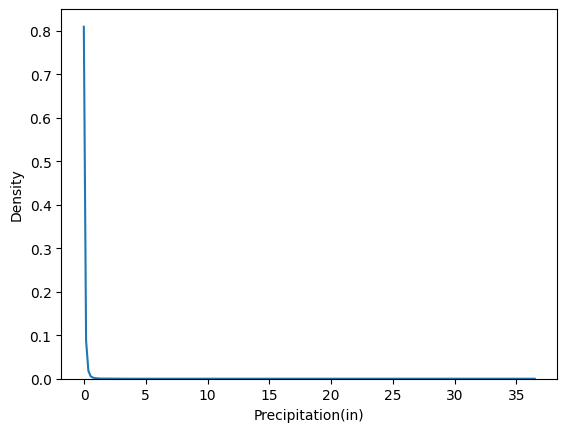

In [49]:
sns.kdeplot(df['Precipitation(in)'])

Precipitation is too skewed and ill-sitributed to impute, we will do feature selection to determine purpose.

Missing Indicator added for now

In [26]:
from feature_engine.imputation import AddMissingIndicator

df = AddMissingIndicator(variables=['Precipitation(in)']).fit_transform(df)

df.fillna({'Precipitation(in)':0},inplace=True)

df.rename(columns={'Precipitation(in)_na' : 'Precipitation Missing'},inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 36 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   County                 category
 3   Temperature(F)         float64 
 4   Humidity(%)            float64 
 5   Pressure(in)           float64 
 6   Visibility(mi)         float64 
 7   Wind_Direction         object  
 8   Wind_Speed(mph)        float64 
 9   Precipitation(in)      float64 
 10  Weather_Condition      object  
 11  Amenity                bool    
 12  Bump                   bool    
 13  Crossing               bool    
 14  Give_Way               bool    
 15  Junction               bool    
 16  No_Exit                bool    
 17  Railway                bool    
 18  Roundabout             bool    
 19  Station                bool    
 20  Stop                   bool    
 21  Traffic_Calming        bool    
 22 

In [ ]:
del dfc
del X
del y
del cat_cols
del columns
del mi
del enc

Arbitrary Impute Wind_Direction & Weather_Condition to Missing

In [14]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='constant',fill_value='Missing')

df[['Wind_Direction','Weather_Condition']] = si.fit_transform(df[['Wind_Direction','Weather_Condition']])

del si

In [28]:
100*(df.isna().sum())/77_00_000

Source                   0.000000
Severity                 0.000000
County                   0.000000
Temperature(F)           0.000000
Humidity(%)              0.000000
Pressure(in)             0.000000
Visibility(mi)           0.000000
Wind_Direction           0.000000
Wind_Speed(mph)          0.000000
Precipitation(in)        0.000000
Weather_Condition        0.000000
Amenity                  0.000000
Bump                     0.000000
Crossing                 0.000000
Give_Way                 0.000000
Junction                 0.000000
No_Exit                  0.000000
Railway                  0.000000
Roundabout               0.000000
Station                  0.000000
Stop                     0.000000
Traffic_Calming          0.000000
Traffic_Signal           0.000000
Sunrise_Sunset           0.299844
Civil_Twilight           0.299844
Nautical_Twilight        0.299844
Astronomical_Twilight    0.299844
Start_Hour               0.000000
End_Hour                 0.000000
Accident Day  

For the Light columns, the values being exactly equal is suspecious.
Lets do a quick pair-wise occurance check

In [29]:
mask_equal = (
    (df['Sunrise_Sunset'].isna() == df['Civil_Twilight'].isna()) &
    (df['Civil_Twilight'].isna() == df['Nautical_Twilight'].isna()) &
    (df['Nautical_Twilight'].isna() == df['Astronomical_Twilight'].isna())
)

(~mask_equal).sum()

np.int64(0)

This Means That every missing value occurs together, we have ~0.3 data missing.

That is ~23,000 rows missing. We can simply arbitray impute to 'Missing'.

In [30]:
df[light_cols].sample(2)

,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7514997,Day,Day,Day,Day
3943949,Day,Day,Day,Day


In [43]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='constant',fill_value='Missing')

df[light_cols] = df[light_cols].replace({None:np.nan})

df[light_cols] = si.fit_transform(df[light_cols])

del si

In [45]:
100*(df.isna().sum())/77_00_000

Source                   0.0
Severity                 0.0
County                   0.0
Temperature(F)           0.0
Humidity(%)              0.0
Pressure(in)             0.0
Visibility(mi)           0.0
Wind_Direction           0.0
Wind_Speed(mph)          0.0
Precipitation(in)        0.0
Weather_Condition        0.0
Amenity                  0.0
Bump                     0.0
Crossing                 0.0
Give_Way                 0.0
Junction                 0.0
No_Exit                  0.0
Railway                  0.0
Roundabout               0.0
Station                  0.0
Stop                     0.0
Traffic_Calming          0.0
Traffic_Signal           0.0
Sunrise_Sunset           0.0
Civil_Twilight           0.0
Nautical_Twilight        0.0
Astronomical_Twilight    0.0
Start_Hour               0.0
End_Hour                 0.0
Accident Day             0.0
Accident Timing          0.0
Accident Year            0.0
Resolution Time          0.0
Days To Resolve          0.0
Start_Day_Ordi

No More Values required to impute

**Imputation Decisions**

* Temperature -> Median Imputation is Good
* Wind Chill -> Has been dropped, it was repeated Information
* Humidity -> Median Imputation is Good
* Pressure -> Median Imputation is Good
* Visibility -> Median Imputation is Good
* Wind Speed -> Median Imputation is Good
* Precipitation -> Missing Indicator added, defaulted to Zero
* Wind Direction -> Arbitrary Imputed to 'Missing'
* Weather Condition -> Arbitrary Imputed to 'Missing'
* Sunrise_Sunset -> Arbitrary Imputed to 'Missing'
* Civil_Twilight -> Arbitrary Imputed to 'Missing'
* Nautical_Twilight -> Arbitrary Imputed to 'Missing'
* Astronomical_Twilight -> Arbitrary Imputed to 'Missing'

**Step 2 - Mutual Information Check**

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 36 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   County                 category
 3   Temperature(F)         float64 
 4   Humidity(%)            float64 
 5   Pressure(in)           float64 
 6   Visibility(mi)         float64 
 7   Wind_Direction         object  
 8   Wind_Speed(mph)        float64 
 9   Precipitation(in)      float64 
 10  Weather_Condition      object  
 11  Amenity                bool    
 12  Bump                   bool    
 13  Crossing               bool    
 14  Give_Way               bool    
 15  Junction               bool    
 16  No_Exit                bool    
 17  Railway                bool    
 18  Roundabout             bool    
 19  Station                bool    
 20  Stop                   bool    
 21  Traffic_Calming        bool    
 22 

In [47]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

# Features and target
X = df.drop(columns=['Severity']).copy()
y = df['Severity']

# Identify categorical columns
cat_cols = (
    X.select_dtypes(
        include=['object', 'category']
    )
    .columns
    .tolist()
)

# Encode categorical columns
enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X[cat_cols] = enc.fit_transform(X[cat_cols].astype(str))

# Identify discrete features
discrete_features = [
    (
        col in cat_cols
        or X[col].dtype == bool
    )
    for col in X.columns
]

# Simple imputation for MI calculation
X = X.fillna(-999)

# Calculate MI
mi = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_features,
    random_state=42
)

# Results
mi_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Mutual Information': mi
    })
    .sort_values(
        'Mutual Information',
        ascending=False
    )
    .reset_index(drop=True)
)

print(mi_df)

                  Feature  Mutual Information
0                  Source            0.365316
1           Accident Year            0.261000
2       Start_Day_Ordinal            0.083215
3         Wind_Speed(mph)            0.080846
4   Precipitation Missing            0.072240
5         Accident Timing            0.068978
6              Start_Hour            0.068943
7                End_Hour            0.067826
8         Resolution Time            0.067636
9                  County            0.065265
10         Temperature(F)            0.034934
11      Weather_Condition            0.023509
12            Humidity(%)            0.022041
13         Wind_Direction            0.016953
14           Pressure(in)            0.016487
15        Days To Resolve            0.016270
16           Accident Day            0.015825
17               Crossing            0.008567
18         Traffic_Signal            0.007735
19                   Stop            0.002486
20  Astronomical_Twilight         

We observe that many values in themselves, do not carry much information.
Plus, all road structure related columns little to no information.
We will check the Road Structure & Light related columns in the Model via *Permutation Importance*

For now, we will drop *Visibility* only.

In [ ]:
df.drop(columns=['Visibility(mi)'],inplace=True)